In [1]:
import vacuumms as v
from IPython.display import Image
import matplotlib.pyplot as plt

## Load configuration and replicate image

In [2]:
gfg=v.Configuration("fcc_unit_cell.gfg")
gfg.setBoxDimensions([1,1,1])
gfg.replicate([3,3,3])   # make replicas 3-deep in each direction

## Generate cavities

In [3]:
ddx = v.DDX(gfg)         # create the DDX (cavity-search) operation
ddx.setNumberOfSamples(1000)
ddx.execute() 
cavs = ddx.getResult()   # retrieve result
cavs.scrubDuplicates()   # remove redundant samples

## Create configuration scene component

In [4]:
cc=v.ConfigurationComponent(gfg)
cc.setTransmit(0.0)    # make it opaque
cc.setPhong(0.9)       # make it shiny

# set view to clip at edges of 2nd cell
cc.setBoxDimensions([2.0,2.0,2.0])
cc.setClip()

## Create cavity scene component

In [5]:

cavc = v.CavityComponent(cavs)
cavc.setPhong(0.6)      # make it shiny
cavc.setTransmit(0.7)   # make it semi-transparent
cavc.setColor("Blue")   # make it Blue

# set view to clip at edges of 2nd cell
cavc.setBoxDimensions([2.0,2.0,2.0])
cavc.setClip()

## Create scene container

In [6]:
scene = v.Scene()
scene.setCameraLocation([4,5,6])
scene.setCameraLookAt([0,0,0])
scene.applyAmbientLight()
scene.setRenderDimensions(1920,1080)
scene.clearLightSources()
scene.addLightSource([100,200,300],"White")

## Add components to scene

In [7]:
scene.addSceneComponent(cc)
scene.addSceneComponent(cavc)

## Render scene

POV-Ray render completed successfully.
POV-Ray temporary file deleted successfully.


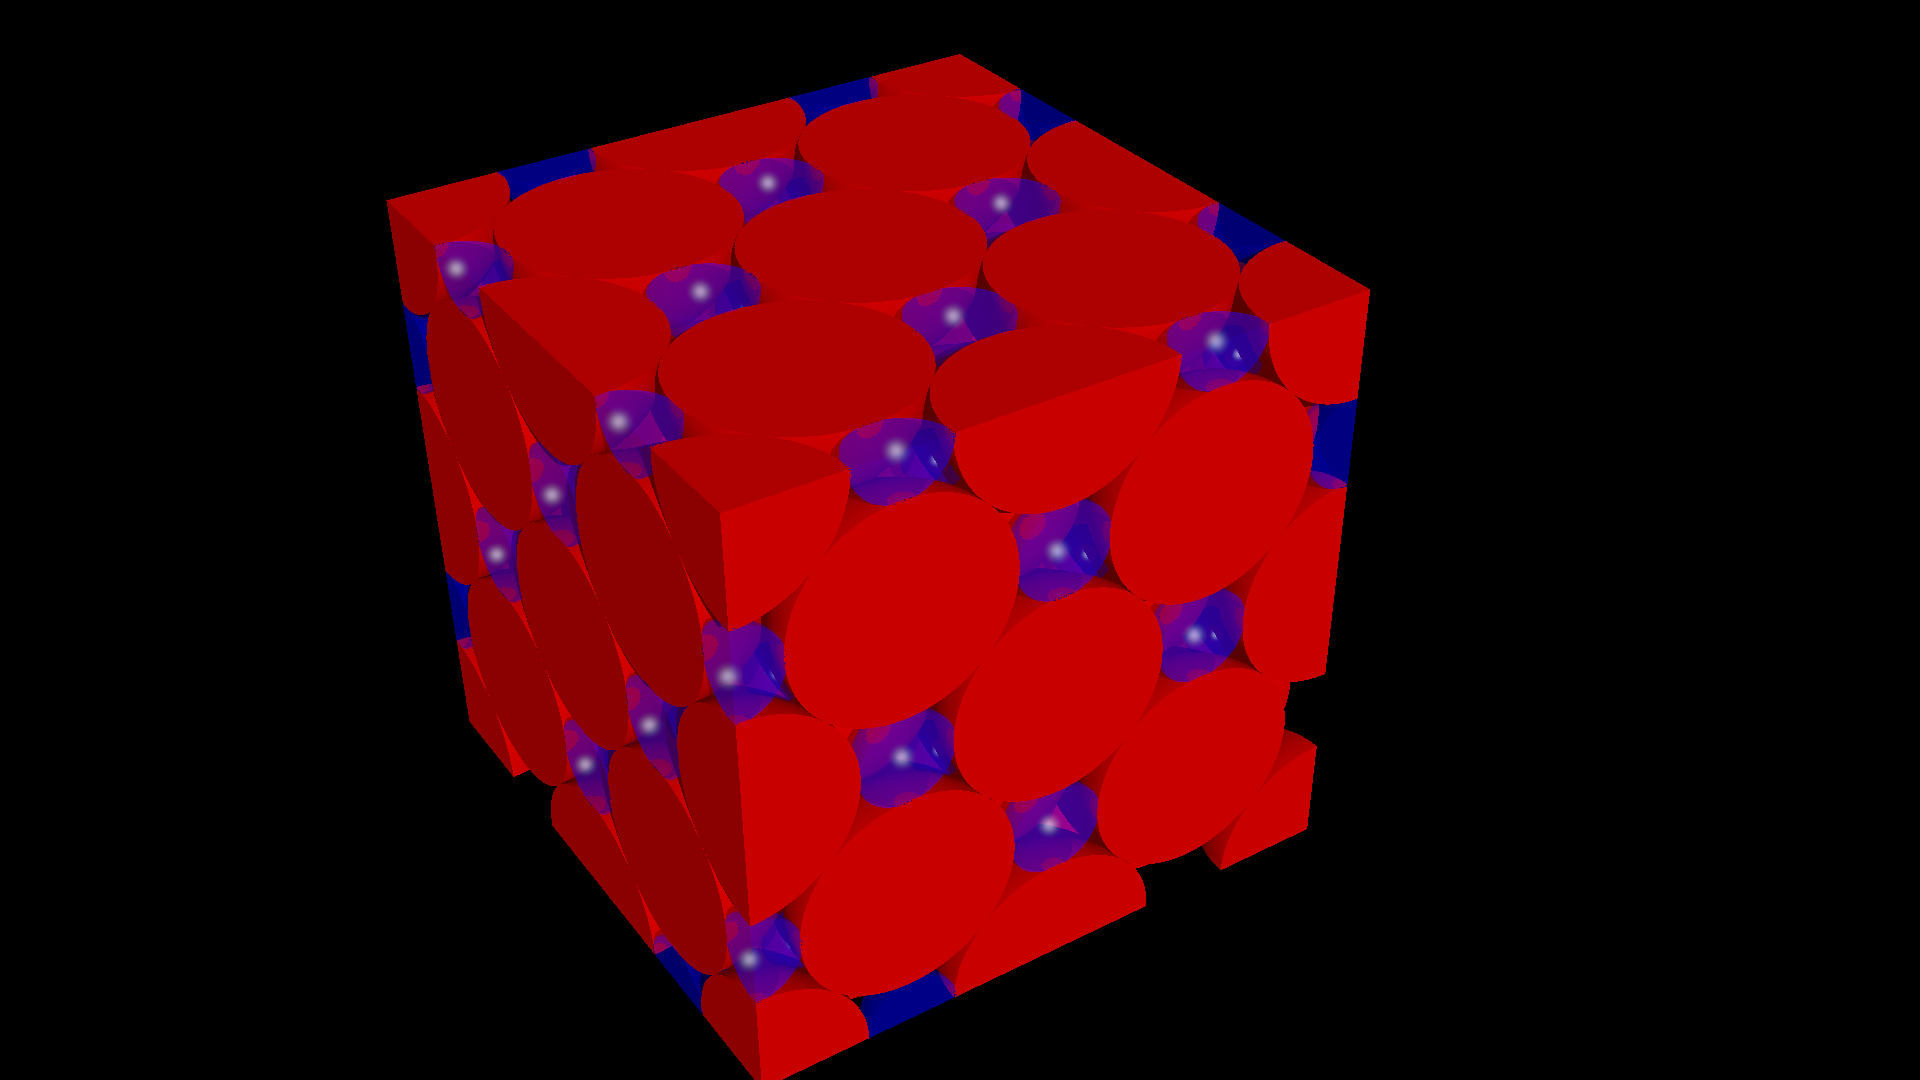

In [8]:
scene.renderScene("fcc.png")
scene.createSceneFile("x.pov")
Image(filename='fcc.png')

## Look at Cavity size distributions / graphs

In [9]:
csd = v.CavitySizeDistribution(cavs)

In [10]:
csd.setBinWidth(0.025)
csd.setNumberOfBins(40)
csd.setStartingValue(0.1)

In [11]:
csd.generate()

In [12]:
csd.setBinWidth(0.025)
csd.setNumberOfBins(41)
csd.setValueRange(0.0, 0.4)

In [13]:
csd.generate()

In [14]:
csd

0.000000:	
0.009756:	
0.019512:	
0.029268:	
0.039024:	
0.048780:	
0.058537:	
0.068293:	
0.078049:	
0.087805:	
0.097561:	
0.107317:	
0.117073:	****
0.126829:	
0.136585:	
0.146341:	
0.156098:	
0.165854:	****************************************************************************************************
0.175610:	
0.185366:	
0.195122:	
0.204878:	
0.214634:	
0.224390:	
0.234146:	
0.243902:	
0.253659:	
0.263415:	
0.273171:	
0.282927:	
0.292683:	
0.302439:	************************************************************************
0.312195:	
0.321951:	
0.331707:	
0.341463:	
0.351220:	
0.360976:	
0.370732:	
0.380488:	
0.390244:	

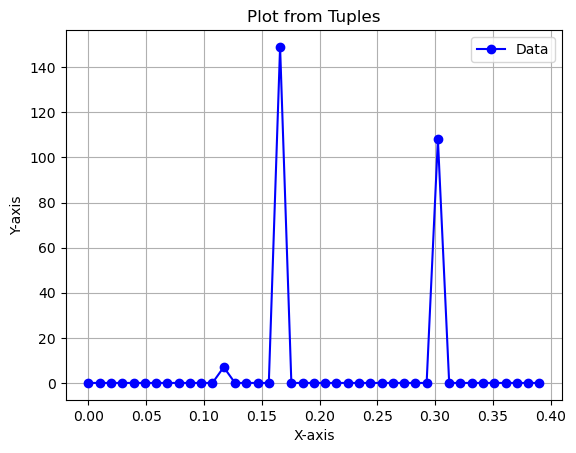

In [17]:
data=csd.getTuples()
x, y = zip(*data)

# Create the plot
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Data')  # Line plot with markers
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Plot from Tuples')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()

In [18]:
csd.applyWeightExponent(3)
csd

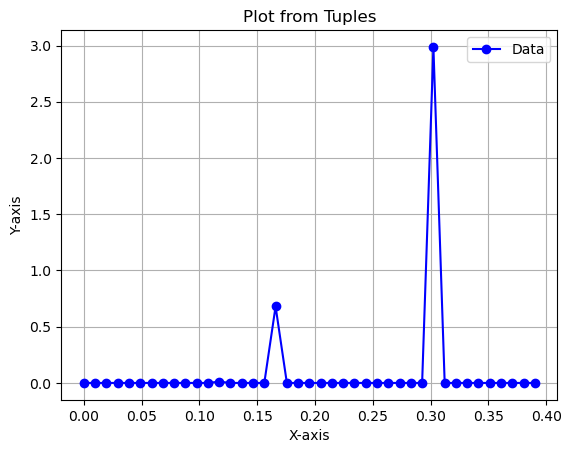

In [20]:
data=csd.getTuples()
x, y = zip(*data)

# Create the plot
plt.plot(x, y, marker='o', linestyle='-', color='b', label='Data')  # Line plot with markers
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Plot from Tuples')
plt.legend()
plt.grid(True)

# Display the plot
plt.show()